In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"beyzahiz","key":"80dc9015b76a77a6a15c99f1d215774b"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nalisha/job-salary-prediction-dataset                              Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000           9769        231                1  
belbino/global-fuel-prices-20202026                                Global Fuel Prices 2020–2026                            420762  2026-04-07 06:43:27.817000           1092         26                1  
rifatalam3/coffee-revenue-dataset                                  Coffee Revenue Dataset                                   38970  2026-04-07 05:32:05.120000            835         25     

In [5]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip brain-tumor-mri-dataset.zip

Görüntülenen çıkış son 5000 satıra kısaltıldı.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  inflatin

In [6]:
!ls

brain-tumor-mri-dataset.zip  kaggle.json  sample_data  Testing	Training


In [7]:
!ls Training

glioma	meningioma  notumor  pituitary


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_dir = "Training"
test_dir = "Testing"

train_datagen = ImageDataGenerator(
    rescale=1./255, #görseller 0-255 iken 0-1.. yapar
    rotation_range=10, #Görselleri ±10 derece döndürür
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory( #bu fonksiyon klasörleri okur, görselleri yükler, label üretir
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [9]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [12]:
#EfficentNet Modeli

from tensorflow.keras.applications import EfficientNetB0
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers[:-50]:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    layer.trainable = True

from tensorflow.keras import layers,models


x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 113s 466ms/step - accuracy: 0.3013 - loss: 1.3735 - val_accuracy: 0.2500 - val_loss: 1.3885
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 423ms/step - accuracy: 0.3573 - loss: 1.2972 - val_accuracy: 0.3663 - val_loss: 1.3903
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 73s 418ms/step - accuracy: 0.3934 - loss: 1.2587 - val_accuracy: 0.4013 - val_loss: 1.2672
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 73s 415ms/step - accuracy: 0.4134 - loss: 1.2189 - val_accuracy: 0.5175 - val_loss: 1.2243
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 423ms/step - accuracy: 0.4402 - loss: 1.1932 - val_accuracy: 0.5206 - val_loss: 1.2086
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 426ms/step - accuracy: 0.4666 - loss: 1.1448 - val_accuracy: 0.4212 - val_loss: 1.3339
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 430ms/step - accuracy: 0.4830 - loss: 1.1178 - val_accuracy: 0.5425 - val_loss: 1.1473
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 429ms/step - accuracy: 0.4971 - loss: 

In [13]:
model.save("mri_model.keras")

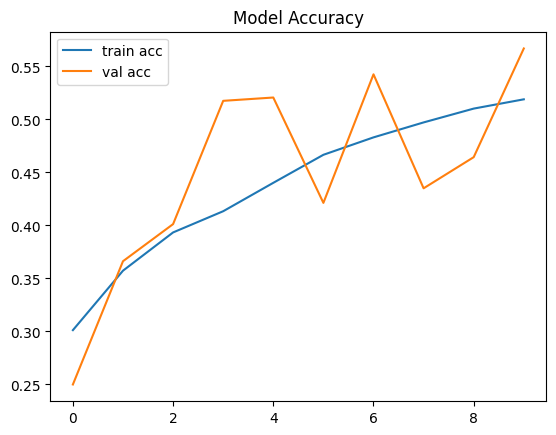

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Model Accuracy")
plt.show()